In [2]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

In [4]:
df = pd.read_csv("metadata.csv")
df_feature = pd.read_csv("results/features_extended.csv")
print(df.shape)
print(df_feature.shape)

(2298, 26)
(2103, 14)


In [5]:
hair_threshold = 0.01
total_images = len(df_feature)
benign = (df_feature["cancer"] == 0).sum()
malignant = (df_feature["cancer"] == 1).sum()
hair_present = (df_feature["hair_coverage"] > hair_threshold).sum()

summary_table = pd.DataFrame({
    "Metric" : [
        "Total images",
        "Benign images",
        "Malignant images",
        "Benign (%)",
        "Malignant (%)",
        "Images with hair (>% threshold)"
    ],
    "Value" : [
        total_images,
        benign,
        malignant,
        f"{benign/total_images:.2%}",
        f"{malignant/total_images:.2%}",
        f"{hair_present/total_images:.2%}"
    ]
})

summary_table

,Metric,Value
0,Total images,2103
1,Benign images,1055
2,Malignant images,1048
3,Benign (%),50.17%
4,Malignant (%),49.83%
5,Images with hair (>% threshold),85.16%


In [37]:
#Feature summary table
feature_summary = pd.DataFrame({
    "Feature": [
        "Asymmetry",
        "Border",
        "Texture",
        "Mean hue(mean_h)",
        "Mean saturation(mean_s)",
        "Mean brightness(mean_v)",
        "Hue standard deviation",
        "Saturation standard deviation",
        "Brightness standard deviation",
        "Hair coverage",
        "Color entropy"
    ],
    "Range": [
        "[0, 1]",
        "[1, ∞)",
        ">= 0",
        "[0, 1]",
        "[0, 1]",
        "[0, 1]",
        ">= 0",
        ">= 0",
        ">= 0",
        "[0, 1]",
        ">= 0"
    ],
    "Interpretation": [
        "Measures shape asymmetry of the lesion",
        "Measures irregularity of the lesion border",
        "Captures texture using gradient information",
        "Average hue (color tone) in the lesion",
        "Average color saturation",
        "Average brightness",
        "Variation of hue within the lesion",
        "Variation of saturation within the lesion",
        "Variation of brightness within the lesion",
        "Fraction of pixels covered by hair",
        "Measures diversity of color distribution (higher = more heterogeneous)"
    ]
})

feature_summary

,Feature,Range,Interpretation
0,Asymmetry,"[0, 1]",Measures shape asymmetry of the lesion
1,Border,"[1, ∞)",Measures irregularity of the lesion border
2,Texture,>= 0,Captures texture using gradient information
3,Mean hue(mean_h),"[0, 1]",Average hue (color tone) in the lesion
4,Mean saturation(mean_s),"[0, 1]",Average color saturation
5,Mean brightness(mean_v),"[0, 1]",Average brightness
6,Hue standard deviation,>= 0,Variation of hue within the lesion
7,Saturation standard deviation,>= 0,Variation of saturation within the lesion
8,Brightness standard deviation,>= 0,Variation of brightness within the lesion
9,Hair coverage,"[0, 1]",Fraction of pixels covered by hair


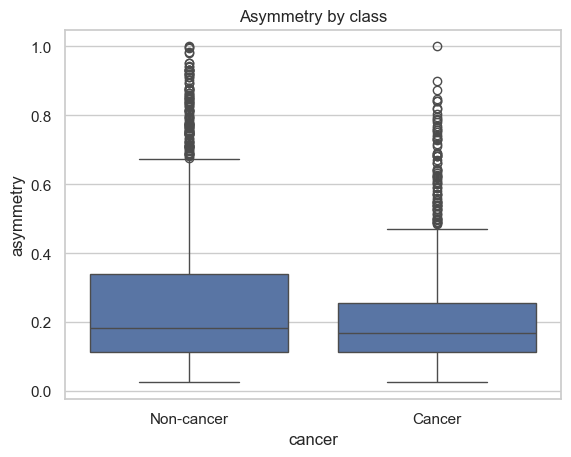

In [18]:
#Asymmetry
sns.boxplot(x="cancer", y="asymmetry", data=df_feature)
plt.title("Asymmetry by class")
plt.xticks([0, 1], ['Non-cancer', 'Cancer'])
plt.show()

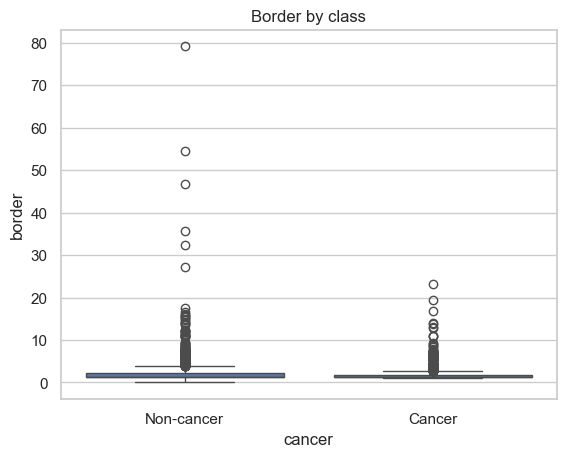

In [17]:
#Border
sns.boxplot(x="cancer", y="border", data=df_feature)
plt.title("Border by class")
plt.xticks([0, 1], ['Non-cancer', 'Cancer'])
plt.show()

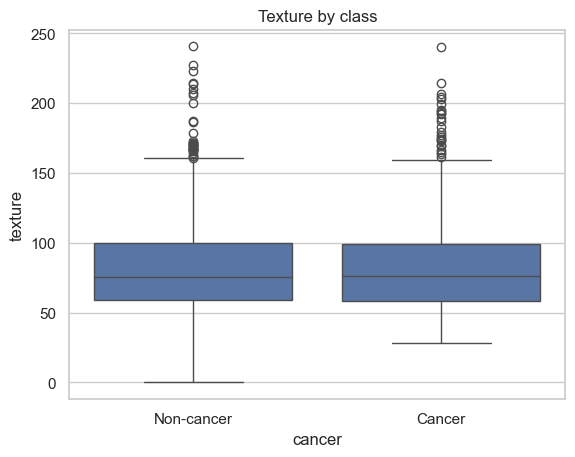

In [16]:
#Texture
sns.boxplot(x="cancer", y="texture", data=df_feature)
plt.title("Texture by class")
plt.xticks([0, 1], ['Non-cancer', 'Cancer'])
plt.show()

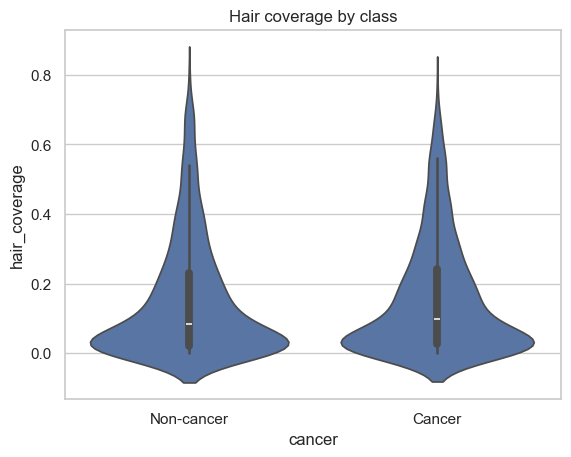

In [15]:
#Hair coverage
sns.violinplot(x="cancer", y="hair_coverage", data = df_feature)
plt.title("Hair coverage by class")
plt.xticks([0, 1], ['Non-cancer', 'Cancer'])
plt.show()

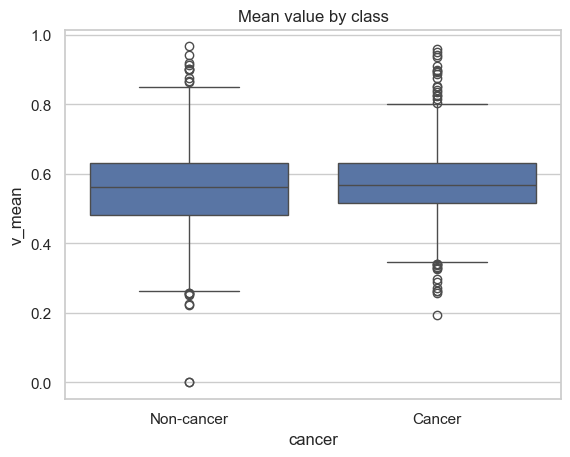

In [21]:
#mean value (brightness)
sns.boxplot(x="cancer", y="v_mean", data=df_feature)
plt.title("Mean value by class")
plt.xticks([0, 1], ['Non-cancer', 'Cancer'])
plt.show()

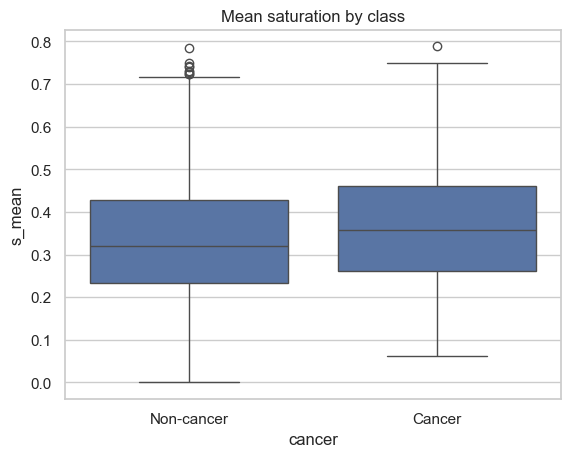

In [22]:
#Mean saturation
sns.boxplot(x="cancer", y="s_mean", data=df_feature)
plt.title("Mean saturation by class")
plt.xticks([0, 1], ['Non-cancer', 'Cancer'])
plt.show()

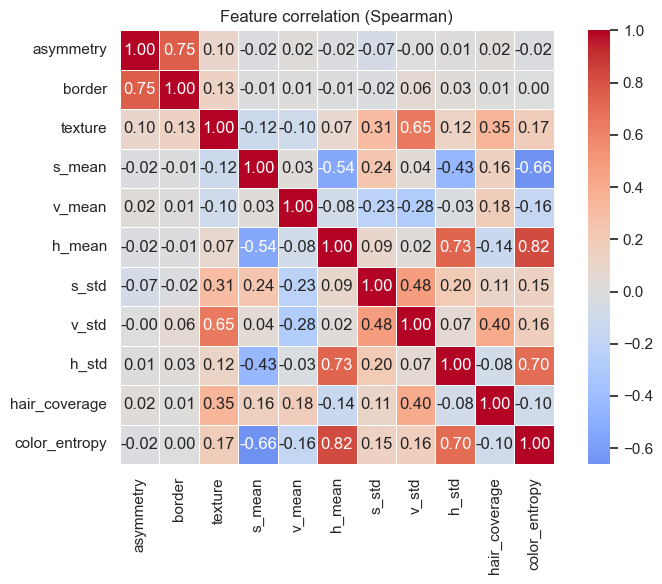

In [34]:
#Correlation matrix
feature_cols = [
    "asymmetry",
    "border",
    "texture",
    "s_mean",
    "v_mean",
    "h_mean",
    "s_std",
    "v_std",
    "h_std",
    "hair_coverage",
    "color_entropy"
]

corr = df_feature[feature_cols].corr(method="spearman")
plt.figure(figsize=(8,6))

sns.heatmap(
    corr,
    cmap = "coolwarm",
    center = 0,
    annot = True,
    fmt = ".2f",
    linewidths=0.5,
    square= True
)

plt.title("Feature correlation (Spearman)")
plt.tight_layout()

plt.show()